# Ownership network topology: two empirical views

The manager-security ownership network is too large to draw directly: a typical
quarter has several thousand managers, several thousand securities, and over a
million holdings edges. Any attempt to render that full bipartite graph as a
node-link diagram would be unreadable in any plotting library.

This notebook is exploratory, not part of the primary evidence chain. It shows
two ways to represent the network's structure at a scale that can actually be
read:

1. **Node-degree distributions** — the pooled distributions of the number of
   securities held per manager and institutional holders per stock across all
   quarterly ownership snapshots.
2. **A community meta-graph** — the full manager-similarity network for the
   same quarter, compressed by collapsing every Louvain community (already
   computed in `notebooks/02_network_analysis/02_manager_communities.ipynb`)
   into a single node. This does represent the complete quarter's community
   structure, not a subsample.

Both read saved pipeline outputs only and do not change any upstream table.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


project_root = Path.cwd().resolve()

while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
networks_directory = paths.interim / "networks"
# The last usable test quarter, so the illustration matches the thesis's own
# held-out period rather than an arbitrary date.
QUARTER = pd.Timestamp("2025-12-31")

print(f"Project root: {project_root}")
print(f"Illustrative quarter: {QUARTER.date()}")

Project root: C:\Users\salio\OneDrive\Desktop\Master Thesis
Illustrative quarter: 2025-12-31


## 1. Node-degree distributions

The two panels use every manager-quarter and stock-quarter observation in the
saved ownership networks. They describe the heterogeneity of the two node
types without relying on a selected network subsample.

In [2]:
manager_nodes = pd.read_parquet(
    networks_directory / "ownership" / "manager_nodes.parquet",
    columns=["security_count"],
)
security_nodes = pd.read_parquet(
    networks_directory / "ownership" / "security_nodes.parquet",
    columns=["institutional_holder_count"],
)

manager_degree = manager_nodes["security_count"].dropna().astype(int)
stock_degree = security_nodes["institutional_holder_count"].dropna().astype(int)

if manager_degree.empty or stock_degree.empty:
    raise RuntimeError("The saved ownership networks contain no node degrees.")

print(f"Manager-quarter observations: {len(manager_degree):,}")
print(f"Stock-quarter observations: {len(stock_degree):,}")

Manager-quarter observations: 251,386
Stock-quarter observations: 206,868


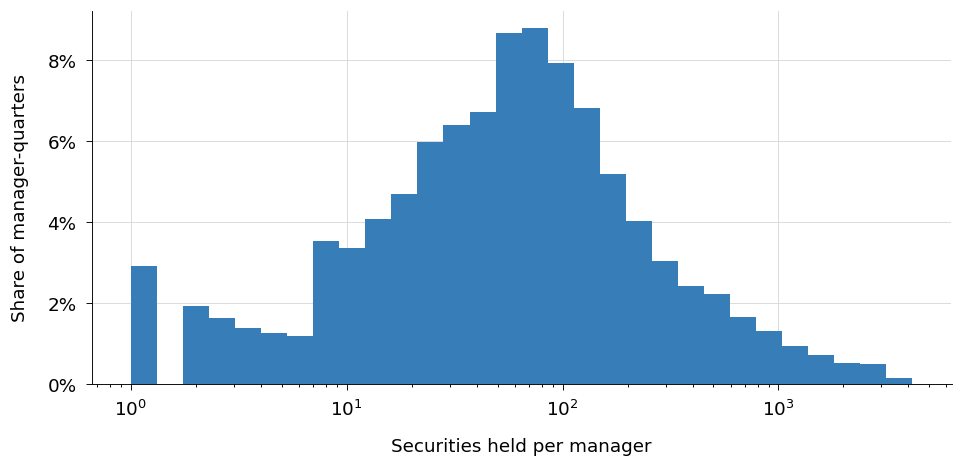

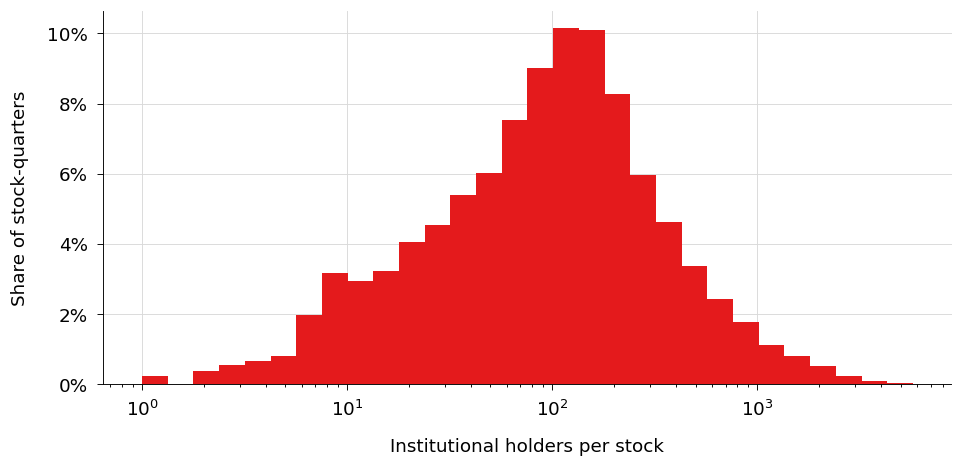

In [3]:
manager_bins = np.geomspace(manager_degree.min(), manager_degree.max() + 1, 31)
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.hist(
    manager_degree,
    bins=manager_bins,
    weights=np.ones(len(manager_degree)) / len(manager_degree),
    color=COLOR_PALETTE[0],
)
axis.set_xscale("log")
axis.set_xlabel("Securities held per manager")
axis.set_ylabel("Share of manager-quarters")
axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "08_01_manager_degree_distribution.pdf")
plt.show()

stock_bins = np.geomspace(stock_degree.min(), stock_degree.max() + 1, 31)
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.hist(
    stock_degree,
    bins=stock_bins,
    weights=np.ones(len(stock_degree)) / len(stock_degree),
    color=COLOR_PALETTE[1],
)
axis.set_xscale("log")
axis.set_xlabel("Institutional holders per stock")
axis.set_ylabel("Share of stock-quarters")
axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "08_01_stock_degree_distribution.pdf")
plt.show()

**Reading this figure.** Both distributions are strongly right-skewed. Most
manager-quarter and stock-quarter nodes have comparatively low degree, while
a smaller group of managers holds many securities and a smaller group of
stocks is held by many institutions. The logarithmic horizontal axes retain
these upper tails without allowing them to compress the main distributions.

## 2. Community meta-graph

This second view does not subsample: it uses every manager-similarity edge
saved for the quarter (all managers, not just the largest), maps each
endpoint to its already-computed Louvain community
(`scripts/10_detect_manager_communities.py`), and aggregates the mean cosine
similarity between every pair of communities. Node size is each community's
manager count.

Because most community pairs have *some* nonzero average similarity, drawing
all of them collapses into an unreadable near-complete graph (91 possible
pairs for the 14 communities in this quarter, 90 with a nonzero mean).
Instead, only the strongest inter-community links are drawn. A community with
no edge shown is not unconnected to the rest of the network -- its average
similarity to other communities fell below what is shown here, not to zero.

In [4]:
TOP_COMMUNITY_PAIRS = 22

manager_communities = pd.read_parquet(
    networks_directory / "manager_communities" / "manager_communities.parquet",
    columns=["report_period", "manager_index", "community_id"],
)
community_summary = pd.read_parquet(
    networks_directory / "manager_communities" / "manager_community_summary.parquet",
    columns=[
        "report_period",
        "community_id",
        "manager_count",
        "total_reported_portfolio_value_usd",
    ],
)
similarity_edges = pd.read_parquet(
    networks_directory / "manager_similarity" / "manager_similarity_edges.parquet",
    columns=[
        "report_period",
        "manager_a_index",
        "manager_b_index",
        "cosine_similarity",
    ],
)

communities_q = manager_communities.loc[manager_communities["report_period"] == QUARTER]
summary_q = community_summary.loc[community_summary["report_period"] == QUARTER]
similarity_q = similarity_edges.loc[similarity_edges["report_period"] == QUARTER]

if communities_q.empty or similarity_q.empty:
    raise RuntimeError(f"No saved community or similarity data for {QUARTER.date()}.")

index_to_community = communities_q.set_index("manager_index")["community_id"].to_dict()
similarity_q = similarity_q.assign(
    community_a=similarity_q["manager_a_index"].map(index_to_community),
    community_b=similarity_q["manager_b_index"].map(index_to_community),
)

if similarity_q[["community_a", "community_b"]].isna().any().any():
    raise RuntimeError("A manager in the similarity edges has no community assignment.")

cross_community = similarity_q.loc[
    similarity_q["community_a"] != similarity_q["community_b"]
].copy()
cross_community["pair"] = cross_community.apply(
    lambda row: tuple(sorted((row["community_a"], row["community_b"]))), axis=1
)
pair_similarity = (
    cross_community.groupby("pair")["cosine_similarity"]
    .agg(mean_similarity="mean", manager_pairs="size")
    .reset_index()
)

possible_pairs = len(summary_q) * (len(summary_q) - 1) // 2
print(f"Communities: {len(summary_q)}")
print(f"Community pairs with a nonzero mean similarity: {len(pair_similarity)} of {possible_pairs} possible")
print(f"Pairs drawn (strongest by mean similarity): {min(TOP_COMMUNITY_PAIRS, len(pair_similarity))}")

Communities: 14
Community pairs with a nonzero mean similarity: 90 of 91 possible
Pairs drawn (strongest by mean similarity): 22


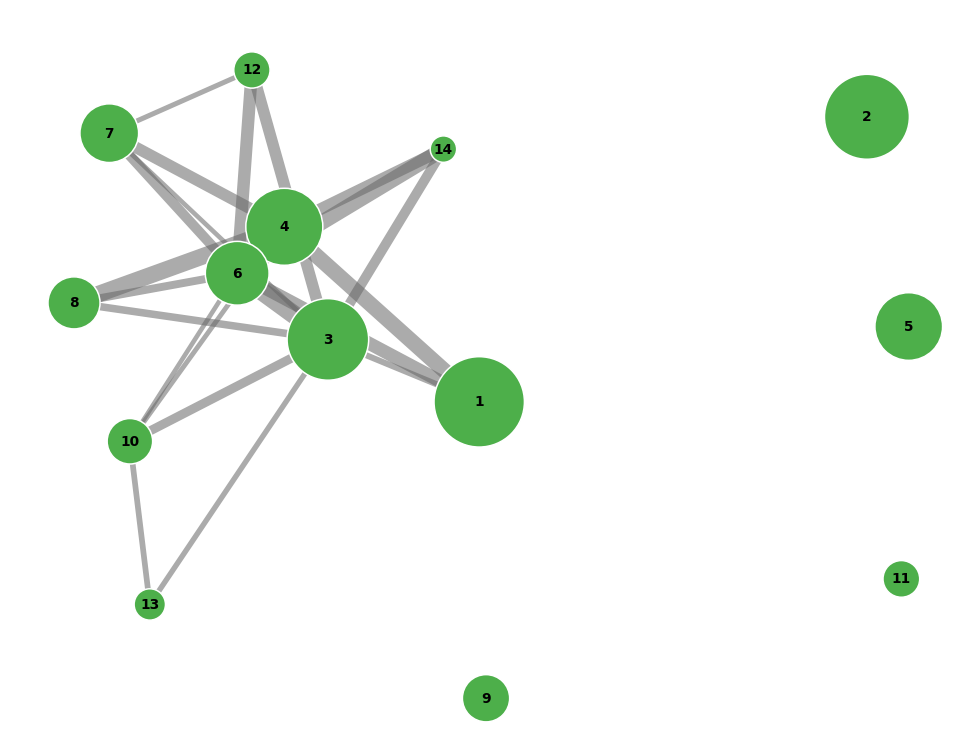

In [5]:
top_pairs = pair_similarity.nlargest(TOP_COMMUNITY_PAIRS, "mean_similarity")

meta_graph = nx.Graph()
for row in summary_q.itertuples(index=False):
    meta_graph.add_node(row.community_id, manager_count=row.manager_count)
for row in top_pairs.itertuples(index=False):
    community_a, community_b = row.pair
    meta_graph.add_edge(community_a, community_b, weight=row.mean_similarity)

manager_counts = pd.Series(nx.get_node_attributes(meta_graph, "manager_count"))
node_sizes = 300 + 3200 * (manager_counts - manager_counts.min()) / (
    manager_counts.max() - manager_counts.min()
)
edge_weights = pd.Series({(u, v): meta_graph[u][v]["weight"] for u, v in meta_graph.edges})
edge_widths = 3 + 12 * (edge_weights - edge_weights.min()) / (
    edge_weights.max() - edge_weights.min()
)

position = nx.spring_layout(meta_graph, weight="weight", seed=13, k=1.1)

figure, axis = plt.subplots(figsize=(9, 7))
nx.draw_networkx_edges(
    meta_graph,
    position,
    width=edge_widths.reindex(meta_graph.edges).tolist(),
    alpha=0.55,
    edge_color="#666666",
    ax=axis,
)
nx.draw_networkx_nodes(
    meta_graph,
    position,
    node_size=node_sizes.reindex(meta_graph.nodes).tolist(),
    node_color=COLOR_PALETTE[2],
    edgecolors="white",
    linewidths=1,
    ax=axis,
)
nx.draw_networkx_labels(meta_graph, position, font_size=9, font_weight="bold", ax=axis)
axis.set_axis_off()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "08_01_community_meta_graph.pdf")
plt.show()

**Reading this figure.** Every community present in the quarter is a node
(unlike the bipartite view above, nothing is subsampled here); node size is
its manager count. Only the twenty-two strongest community pairs by mean
cosine similarity are drawn, out of up to ninety-one possible pairs, so that
the strongest structure is legible. Communities that appear isolated in this
layout still had a measurable average similarity to others -- it was simply
weaker than the pairs shown, not zero. What the figure does show honestly:
whether the community structure has a dense, tightly linked core versus a
looser set of comparably-distant communities in this quarter.